# UMAP on Fashion-MNIST

This notebook applies UMAP to **Fashion-MNIST** (10 clothing classes) and compares it against
PCA and t-SNE. It then clusters the data with DBSCAN, hierarchical clustering and Gaussian mixture
models, so it's easy to judge at a glance whether each method recovers the known
class structure.

Fashion-MNIST is a harder test than handwritten digits: shirts, coats, pullovers and tops look
very similar at the pixel level, so perfect separation isn't expected.

We'll:
1. Load Fashion-MNIST and flatten each image into a feature vector
2. Embed with UMAP, PCA and t-SNE, colored by true label
3. Explore UMAP's key parameters and a 3D embedding
4. Cluster with DBSCAN, hierarchical clustering and Gaussian mixture models, with short
   insights after each block

> **Note:** This notebook downloads data from OpenML the first time it runs (`fetch_openml`),
> so it needs internet access. Run it locally or in Google Colab if your environment
> restricts outbound network access.

## 1. Import the necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import umap

np.random.seed(42)

## 2. Load Fashion-MNIST

- `fetch_openml("Fashion-MNIST")` pulls the full 70,000-image dataset.
- We subsample to 10,000 images — plenty to see clean cluster separation — and scale pixels to [0, 1].

In [2]:
fashion = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
X_fashion, y_fashion = fashion.data, fashion.target.astype(int)

X_fashion, _, y_fashion, _ = train_test_split(
    X_fashion, y_fashion, train_size=10_000, stratify=y_fashion, random_state=42
)
X_fashion = X_fashion / 255.0

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

print(X_fashion.shape, y_fashion.shape)

(10000, 784) (10000,)


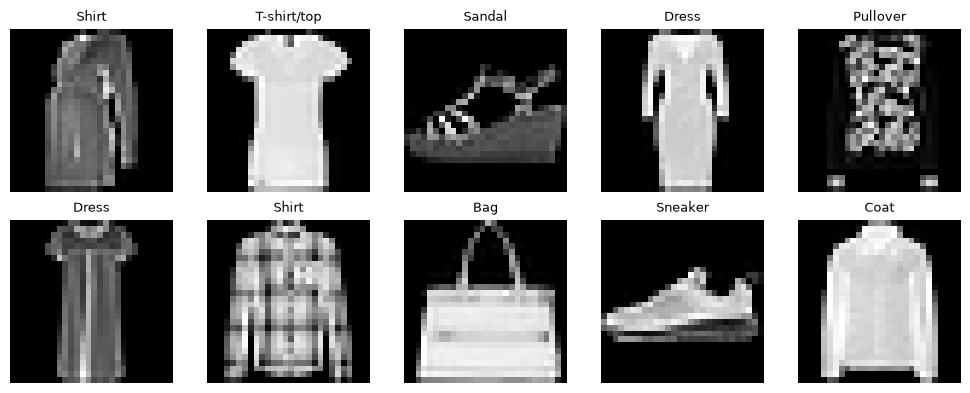

In [3]:
# a few sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_fashion[i].reshape(28, 28), cmap="gray")
    ax.set_title(class_names[y_fashion[i]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

- Each image is just a 784-dimensional vector of pixel intensities.

## 3. UMAP embedding of Fashion-MNIST

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


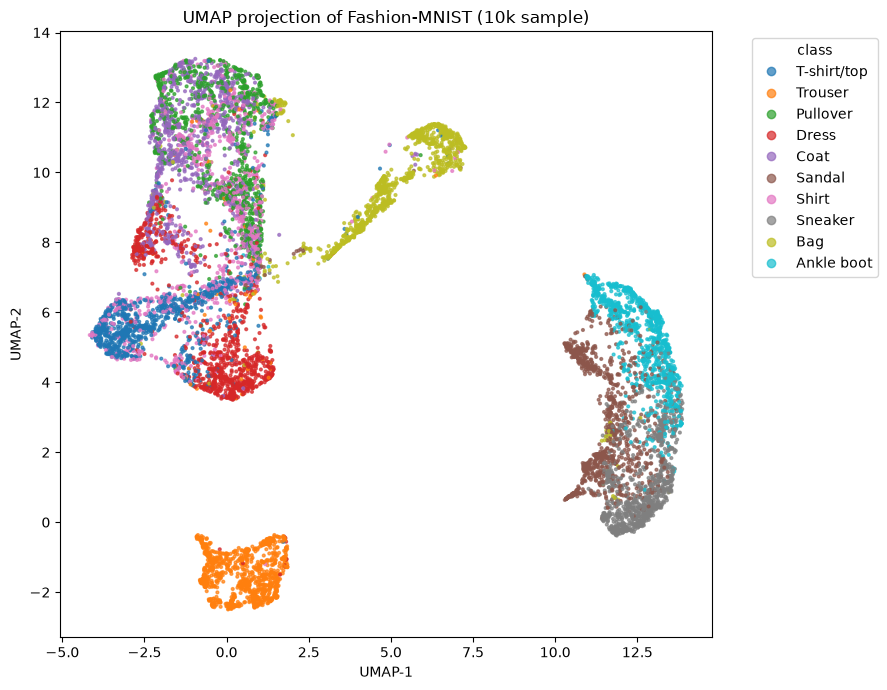

In [4]:
reducer_fashion = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_fashion = reducer_fashion.fit_transform(X_fashion)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    embedding_fashion[:, 0], embedding_fashion[:, 1],
    c=y_fashion, cmap="tab10", s=4, alpha=0.7
)
handles, _ = scatter.legend_elements()
plt.legend(handles, class_names, title="class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("UMAP projection of Fashion-MNIST (10k sample)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

- The separation is visibly *not* clean — some classes mix heavily.
- That's the interesting result: shirts, coats, pullovers and tops look very similar at the pixel level.
- UMAP isn't failing; it's exposing a real limit of 2D pixel similarity.

## 4. Compare against PCA and t-SNE

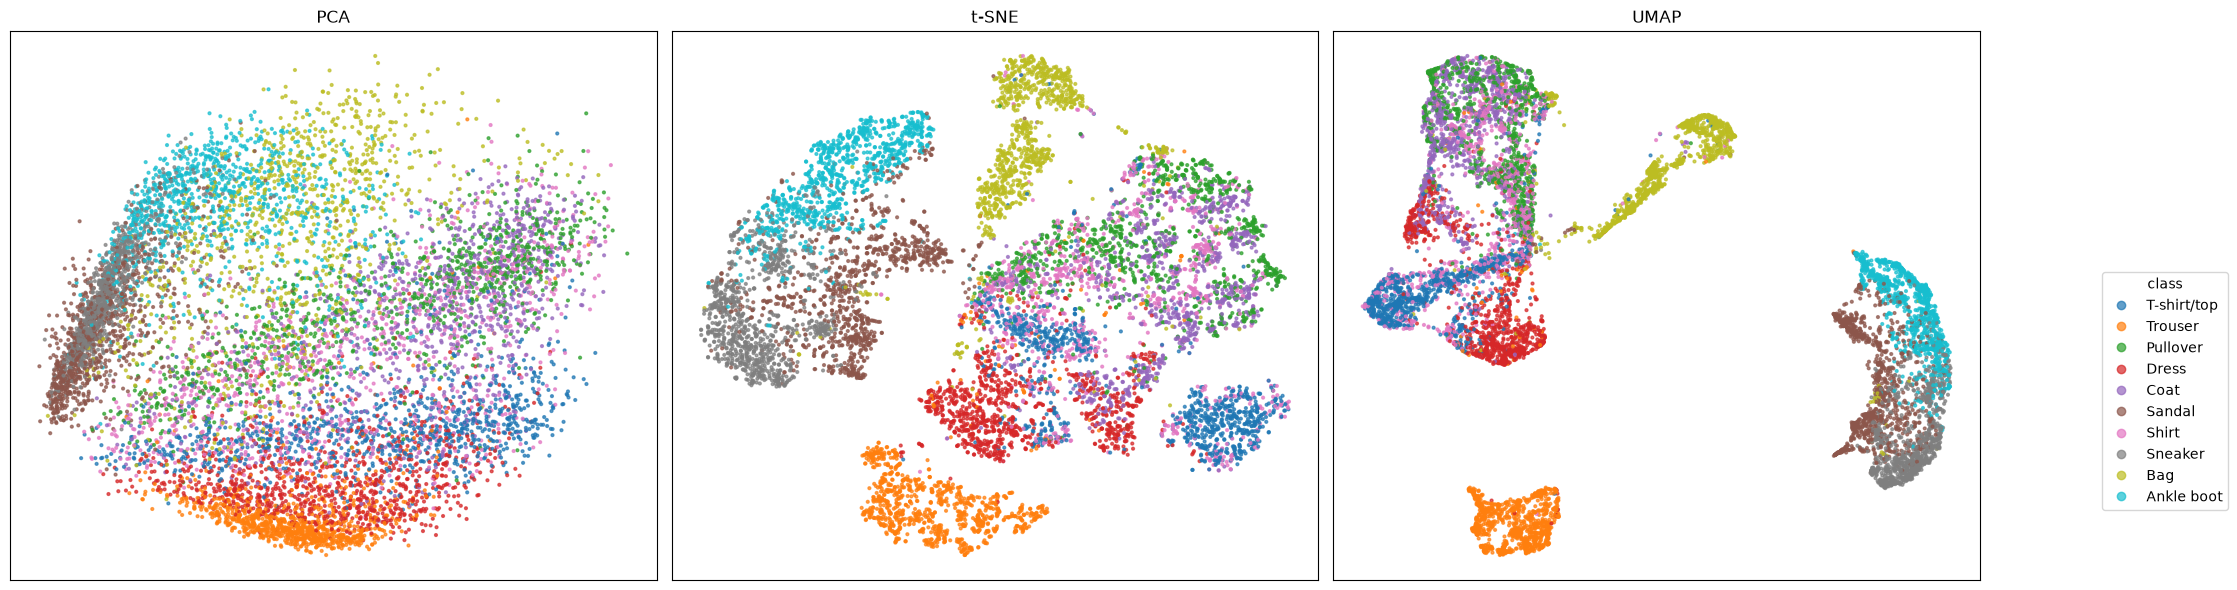

In [5]:
pca = PCA(n_components=2, random_state=42)
embedding_pca = pca.fit_transform(X_fashion)

tsne = TSNE(n_components=2, random_state=42, init="pca", perplexity=30)
embedding_tsne = tsne.fit_transform(X_fashion)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, emb, title in zip(
    axes,
    [embedding_pca, embedding_tsne, embedding_fashion],
    ["PCA", "t-SNE", "UMAP"],
):
    sc_ = ax.scatter(emb[:, 0], emb[:, 1], c=y_fashion, cmap="tab10", s=4, alpha=0.7)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
handles, _ = sc_.legend_elements()
fig.legend(handles, class_names, title="class", bbox_to_anchor=(1.05, 0.55), loc="upper left")
plt.tight_layout()
plt.show()

- **PCA** captures only linear variance, so classes overlap heavily.
- **t-SNE** and **UMAP** both produce visually tighter clusters.
- UMAP typically runs faster on this size of dataset and keeps some rough global
  relationships between clusters, whereas t-SNE optimizes almost purely for local structure.

## 5. Interactive effect of UMAP's key parameters

In [6]:
import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display
from functools import lru_cache

# Smaller subsample keeps the live parameter sweep responsive.
X_param, _, y_param, _ = train_test_split(
    X_fashion, y_fashion, train_size=1_200, stratify=y_fashion, random_state=42
)

# Cache embeddings per (n_neighbors, min_dist) so re-visits are instant.
@lru_cache(maxsize=32)
def embed(n_neighbors, min_dist):
    # No fixed seed here: it lets UMAP parallelize with n_jobs=-1.
    # Results stay consistent within the session via the cache above.
    reducer = umap.UMAP(
        n_neighbors=int(n_neighbors), min_dist=min_dist, n_jobs=-1
    )
    return reducer.fit_transform(X_param)

fig = go.Figure(
    go.Scattergl(
        x=[], y=[],
        mode="markers",
        marker=dict(
            size=5, opacity=0.7,
            color=y_param, colorscale="Jet", cmin=0, cmax=9,
            colorbar=dict(title="class"),
        ),
    )
)
fig.update_layout(
    title="UMAP on Fashion-MNIST - n_neighbors=15, min_dist=0.10",
    xaxis_title="UMAP-1",
    yaxis_title="UMAP-2",
    width=720,
    height=500,
    template="plotly_white",
)

out = widgets.Output()

def update_plot(*_):
    e = embed(nn_slider.value, md_slider.value)
    with out:
        out.clear_output(wait=True)
        fig.data[0].x, fig.data[0].y = e.T
        fig.layout.title.text = (
            f"UMAP on Fashion-MNIST - n_neighbors={nn_slider.value}, min_dist={md_slider.value:.2f}"
        )
        display(fig)

nn_slider = widgets.IntSlider(
    value=15, min=5, max=60, step=5, description="n_neighbors",
    continuous_update=False, layout=widgets.Layout(width="320px"),
)
md_slider = widgets.FloatSlider(
    value=0.1, min=0.0, max=1.0, step=0.05, description="min_dist",
    continuous_update=False, layout=widgets.Layout(width="320px"),
)

nn_slider.observe(update_plot, names="value")
md_slider.observe(update_plot, names="value")
update_plot()

display(widgets.VBox([out, widgets.HBox([nn_slider, md_slider])]))

- Drag the `n_neighbors` and `min_dist` sliders — the embedding recomputes when you release a slider.
- Results are cached per parameter combination, so revisiting a combination is instant.
- `min_dist` controls how tightly points within a cluster are packed: low values (0.0) give dense,
  tight blobs; high values (1.0) spread points out and reveal a cluster's internal shape.
- `n_neighbors` controls local vs global structure: small values give more, tighter clusters;
  large values smooth toward coarser, global structure.
- Since the ranges overlap, min_dist values below ~0.3 mostly affect cluster tightness, not count.

## 6. A 3D UMAP embedding of Fashion-MNIST

In [7]:
import plotly.express as px
import pandas as pd

reducer_3d = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
embedding_fashion_3d = reducer_3d.fit_transform(X_fashion)

df_3d = pd.DataFrame(embedding_fashion_3d, columns=["UMAP-1", "UMAP-2", "UMAP-3"])
df_3d["class"] = [class_names[int(i)] for i in y_fashion]

fig = px.scatter_3d(
    df_3d, x="UMAP-1", y="UMAP-2", z="UMAP-3",
    color="class", category_orders={"class": class_names},
    opacity=0.7, height=700,
    title="3D UMAP projection of Fashion-MNIST (10k sample) — drag to rotate",
)
fig.update_traces(marker=dict(size=2))
fig.show()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


- In 3D, categories that overlap in 2D projections get a bit more separation.
- The extra dimension reveals more structure within clusters, though visually similar
  classes (shirts vs pullovers vs coats) still blend together.

## 7. DBSCAN clustering

DBSCAN groups points that are packed closely together and flags isolated points as **noise**. Unlike
K-Means you don't tell it how many clusters to expect, and it can find clusters of any shape.

It needs two settings:
- **eps** — how far apart points can be and still count as neighbors
- **min_samples** — how many neighbors a point needs to start a cluster

We run it two ways and compare:
1. on the **raw pixels** — where distances are distorted in 784 dimensions
2. on the **UMAP embedding** — where distances mean something again

In [8]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler

### 7.1 On the raw pixels

In [9]:
# Standardize first: DBSCAN is distance-based, so scaling matters
X_fashion_scaled = StandardScaler().fit_transform(X_fashion)

dbscan_raw = DBSCAN(eps=10.0, min_samples=5, n_jobs=-1)
labels_raw = dbscan_raw.fit_predict(X_fashion_scaled)

n_clusters = len(set(labels_raw)) - (1 if -1 in labels_raw else 0)
n_noise = list(labels_raw).count(-1)
ari_raw = adjusted_rand_score(y_fashion, labels_raw)
nmi_raw = normalized_mutual_info_score(y_fashion, labels_raw)

print(f"Clusters: {n_clusters} | Noise: {100 * n_noise / len(labels_raw):.1f}%")

Clusters: 25 | Noise: 85.7%


In [10]:
# to check the value counts in each cluster
print(pd.Series(labels_raw).value_counts())

-1     8574
 1      674
 3      326
 7      125
 2       62
 6       32
 16      24
 10      24
 5       23
 0       21
 9       15
 4       13
 12      10
 8        9
 13       9
 14       8
 18       6
 22       6
 17       6
 11       5
 20       5
 19       5
 23       5
 21       5
 15       4
 24       4
Name: count, dtype: int64


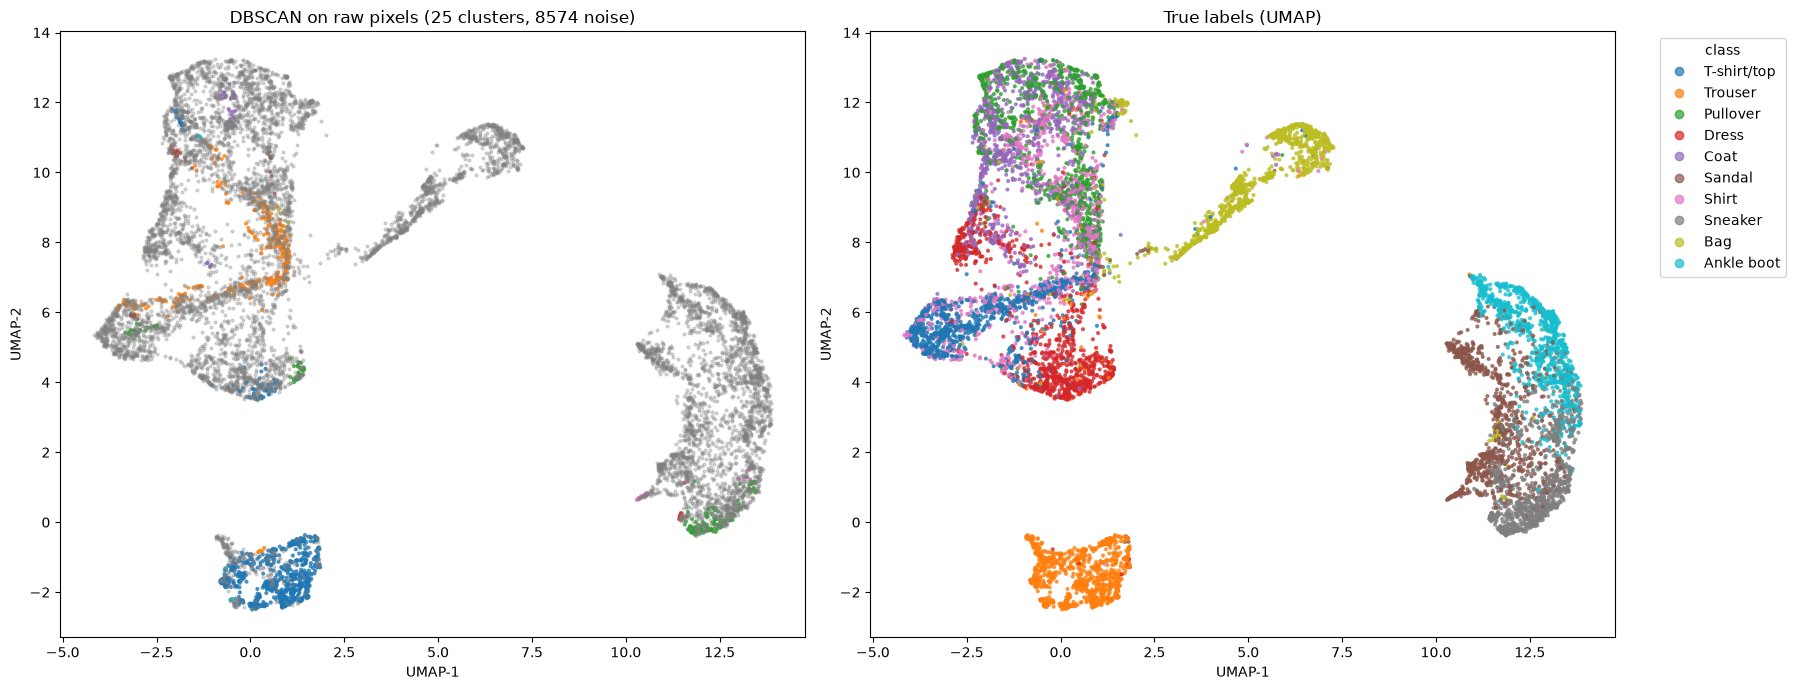

In [11]:
# Visualize DBSCAN clusters on the UMAP embedding (gray = noise)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

noise_mask = labels_raw == -1
axes[0].scatter(
    embedding_fashion[~noise_mask, 0], embedding_fashion[~noise_mask, 1],
    c=labels_raw[~noise_mask], cmap="tab10", s=4, alpha=0.7
)
axes[0].scatter(
    embedding_fashion[noise_mask, 0], embedding_fashion[noise_mask, 1],
    c="gray", s=4, alpha=0.3, label="noise"
)
axes[0].set_title(f"DBSCAN on raw pixels ({n_clusters} clusters, {n_noise} noise)")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

scatter = axes[1].scatter(
    embedding_fashion[:, 0], embedding_fashion[:, 1],
    c=y_fashion, cmap="tab10", s=4, alpha=0.7
)
handles, _ = scatter.legend_elements()
axes[1].legend(handles, class_names, title="class", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].set_title("True labels (UMAP)")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()

- In 784 dimensions every pair of points is about equally far away, so DBSCAN can't find density gaps.
- 86% of points are labelled **noise**; the rest get parceled into stray micro-clusters.

### 7.2 On the UMAP embedding

In [12]:
dbscan_embed = DBSCAN(eps=0.2, min_samples=20, n_jobs=-1)
labels_embed = dbscan_embed.fit_predict(embedding_fashion)

n_clusters = len(set(labels_embed)) - (1 if -1 in labels_embed else 0)
n_noise = list(labels_embed).count(-1)
ari_embed = adjusted_rand_score(y_fashion, labels_embed)
nmi_embed = normalized_mutual_info_score(y_fashion, labels_embed)

print(f"Clusters: {n_clusters} | Noise: {100 * n_noise / len(labels_embed):.1f}%")

Clusters: 28 | Noise: 8.5%


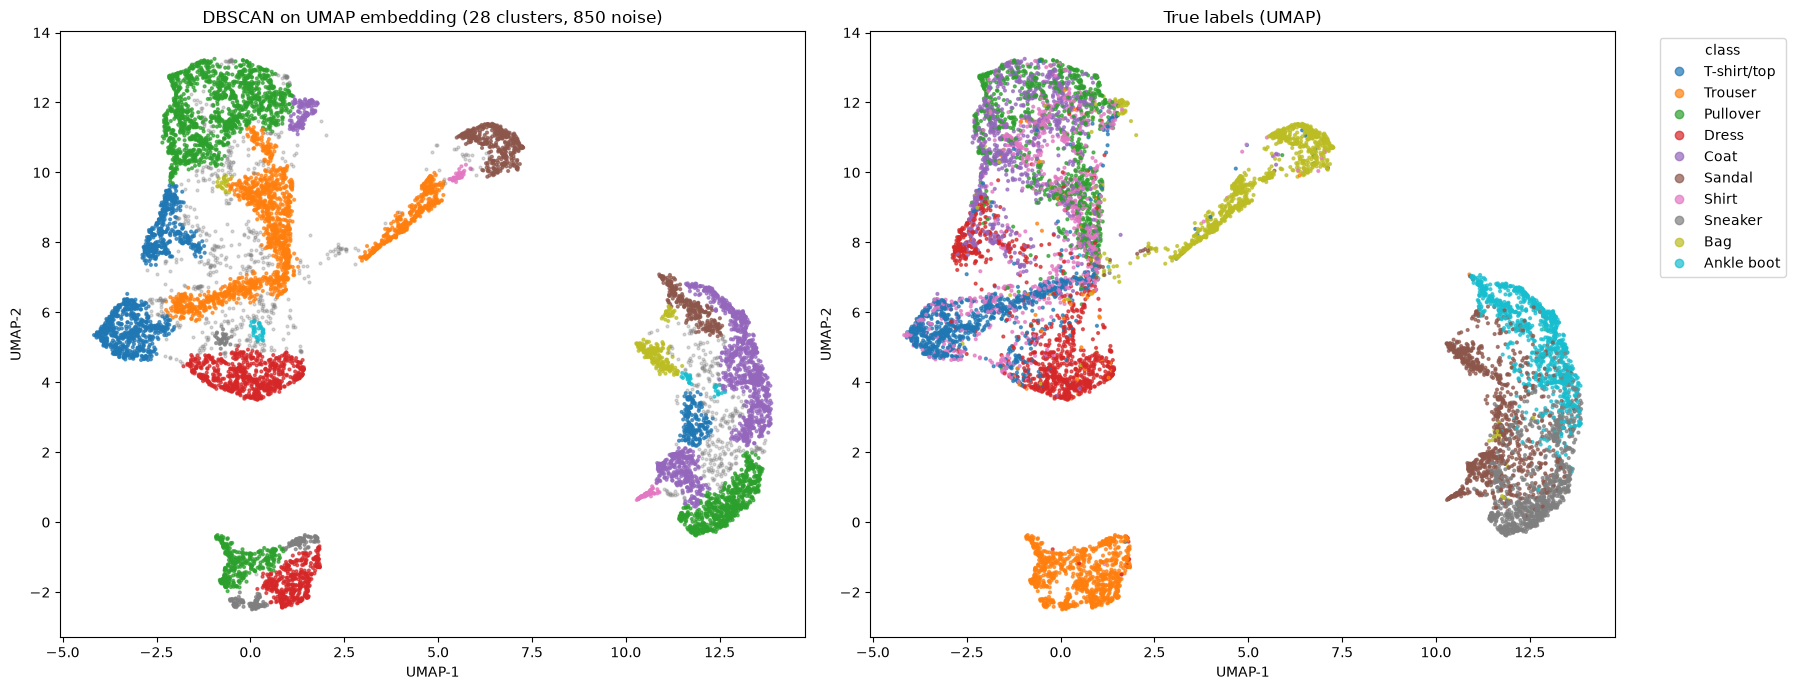

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

noise_mask = labels_embed == -1
axes[0].scatter(
    embedding_fashion[~noise_mask, 0], embedding_fashion[~noise_mask, 1],
    c=labels_embed[~noise_mask], cmap="tab10", s=4, alpha=0.7
)
axes[0].scatter(
    embedding_fashion[noise_mask, 0], embedding_fashion[noise_mask, 1],
    c="gray", s=4, alpha=0.3, label="noise"
)
axes[0].set_title(f"DBSCAN on UMAP embedding ({n_clusters} clusters, {n_noise} noise)")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

scatter = axes[1].scatter(
    embedding_fashion[:, 0], embedding_fashion[:, 1],
    c=y_fashion, cmap="tab10", s=4, alpha=0.7
)
handles, _ = scatter.legend_elements()
axes[1].legend(handles, class_names, title="class", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].set_title("True labels (UMAP)")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()

- In the UMAP space DBSCAN works much better: noise drops from ~86% to ~9%
- It still doesn't find the 10 classes: it splits classes into micro-clusters and merges overlapping ones.
- Density alone can't untangle classes that touch — a good setup for hierarchical clustering next.

## 8. Hierarchical clustering

In [14]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

### 8.1 Hierarchical clustering on Fashion-MNIST

We fix `n_clusters=10` to match the 10 clothing classes, then score the flat partition with ARI and NMI.

In [15]:
hier = AgglomerativeClustering(n_clusters=10, linkage="ward")
labels_hier = hier.fit_predict(embedding_fashion)

ari_hier = adjusted_rand_score(y_fashion, labels_hier)
nmi_hier = normalized_mutual_info_score(y_fashion, labels_hier)
print(f"ARI: {ari_hier:.4f} | NMI: {nmi_hier:.4f}")

ARI: 0.4604 | NMI: 0.6216


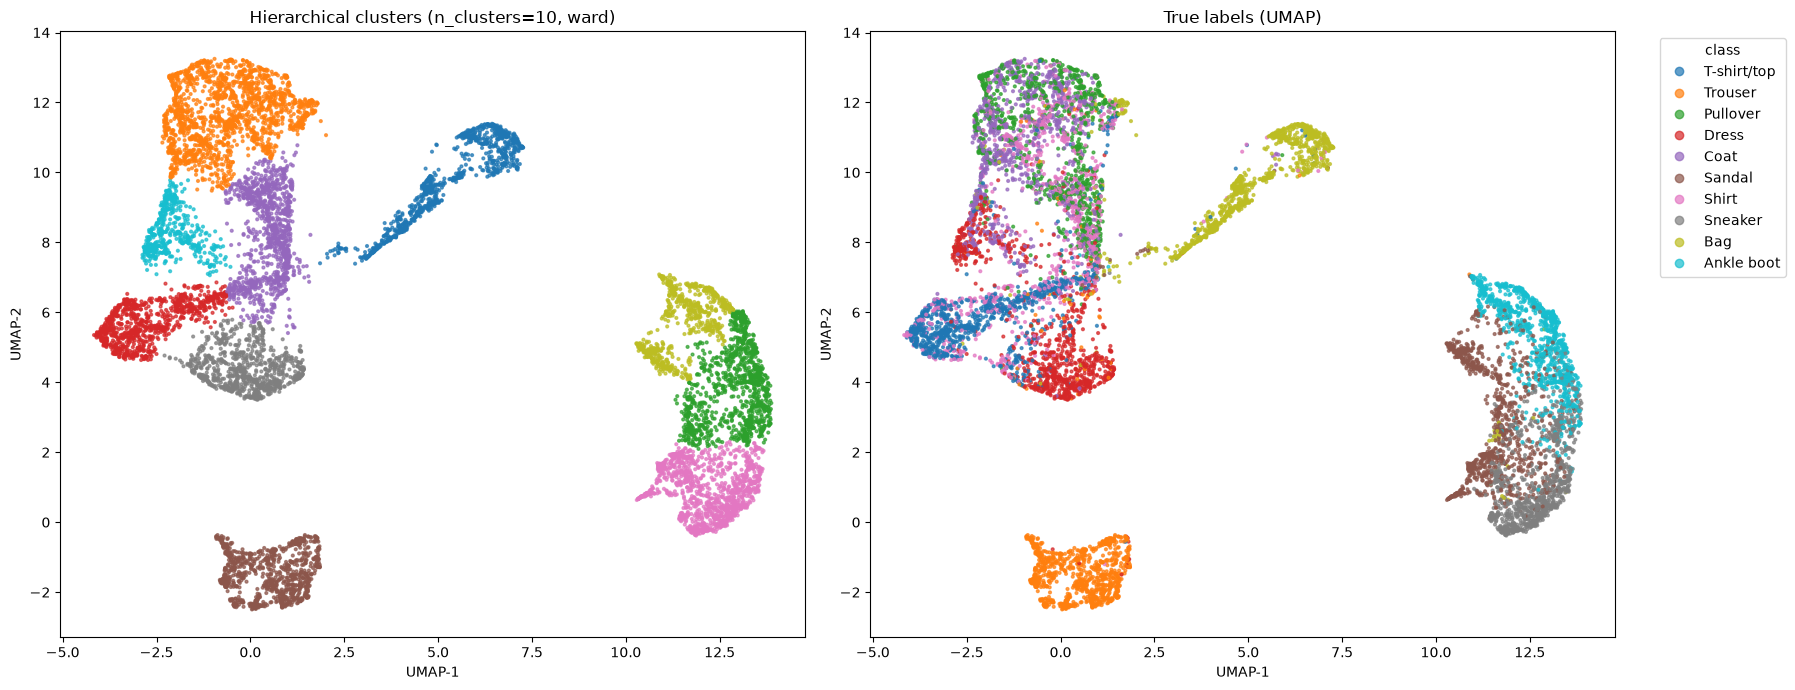

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].scatter(
    embedding_fashion[:, 0], embedding_fashion[:, 1],
    c=labels_hier, cmap="tab10", s=4, alpha=0.7
)
axes[0].set_title("Hierarchical clusters (n_clusters=10, ward)")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

scatter = axes[1].scatter(
    embedding_fashion[:, 0], embedding_fashion[:, 1],
    c=y_fashion, cmap="tab10", s=4, alpha=0.7
)
handles, _ = scatter.legend_elements()
axes[1].legend(handles, class_names, title="class", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].set_title("True labels (UMAP)")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()

- Agglomerative clustering on the UMAP embedding already beats DBSCAN's best ARI, with zero tuning.
- Classes that sit apart in UMAP space (shoes, trousers, bags) come out clean; confusable
  tops and shirts still mix.

### 8.2 The dendrogram

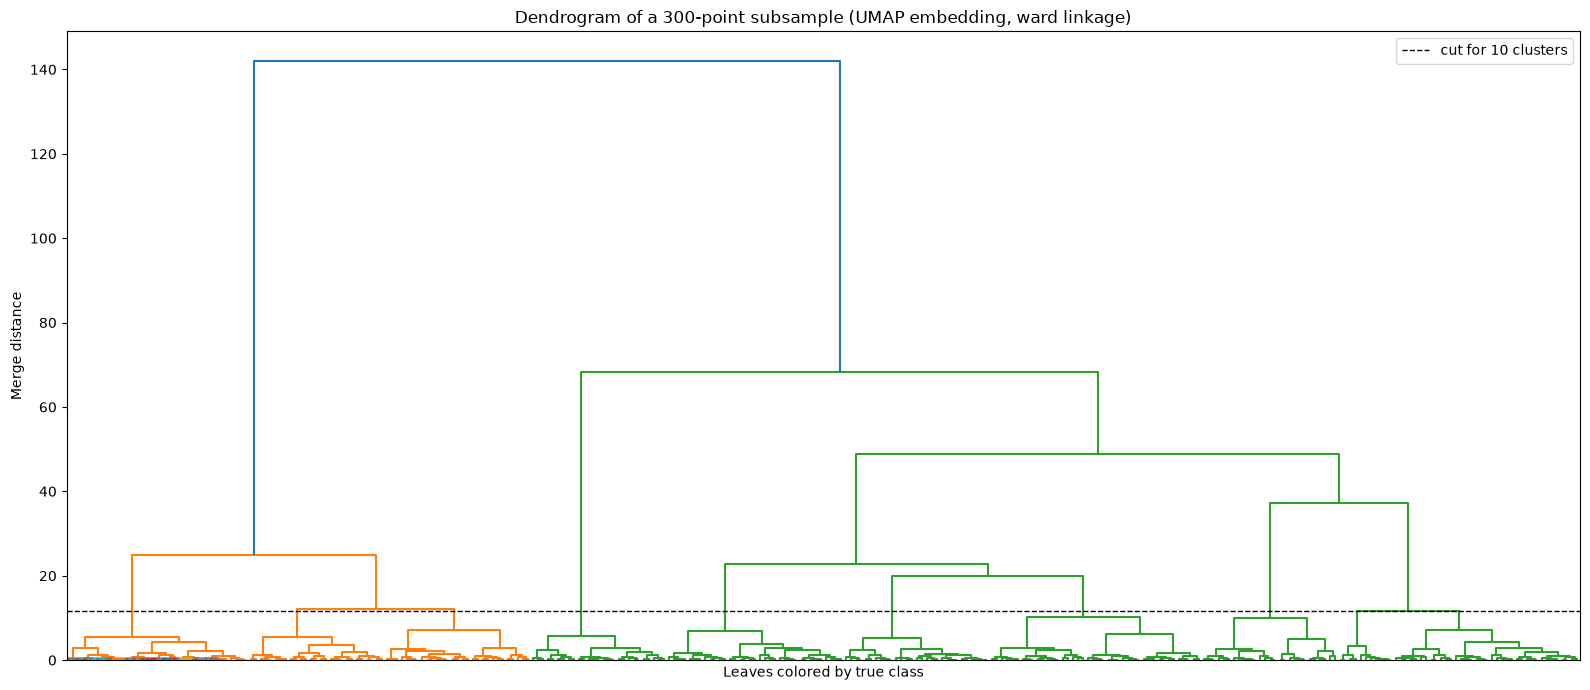

In [17]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_fashion), size=300, replace=False)
emb_sample = embedding_fashion[sample_idx]
y_sample = y_fashion[sample_idx]

Z = linkage(emb_sample, method="ward")

plt.figure(figsize=(16, 7))
dendro = dendrogram(Z, no_labels=True, color_threshold=0.7 * Z[:, 2].max())
leaves = dendro["leaves"]
for pos, leaf_idx in enumerate(leaves):
    plt.plot(pos, 0, "o", color=f"C{int(y_sample[leaf_idx])}", markersize=3)

cut_10 = Z[-9, 2]
plt.axhline(cut_10, color="black", linestyle="--", linewidth=1, label="cut for 10 clusters")
plt.title("Dendrogram of a 300-point subsample (UMAP embedding, ward linkage)")
plt.xlabel("Leaves colored by true class")
plt.ylabel("Merge distance")
plt.legend()
plt.tight_layout()
plt.show()

- Same-class leaves merge into their own subtrees before any large cross-class merges — a clean hierarchy.
- Cutting the tree lower reveals sub-groups inside each class (styles, shapes, edge details).
- The dashed line marks the 10-cluster cut used in 8.1.

## 9. Gaussian Mixture Models

In [18]:
from sklearn.mixture import GaussianMixture

### 9.1 Choosing the number of components with BIC / AIC

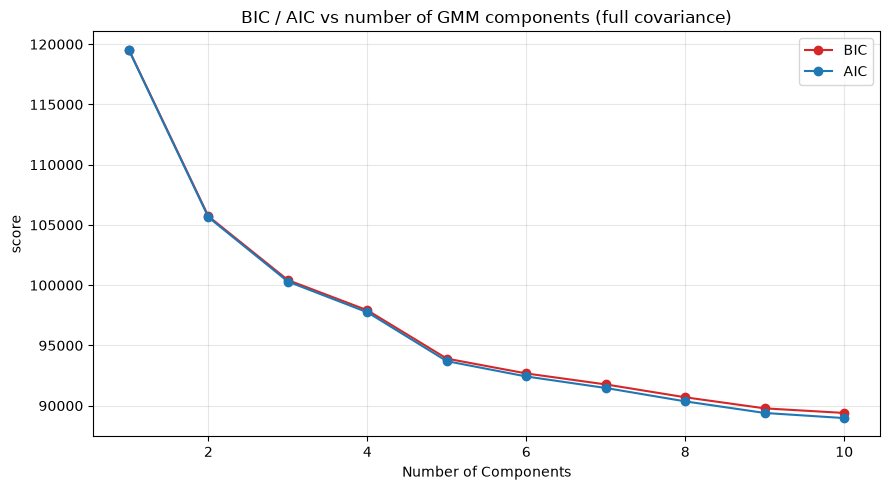

Lowest in sweep -> BIC: k=10 | AIC: k=10


In [52]:
# Sweep n_components on the full-covariance GMM and record AIC / BIC.
n_components_grid = np.arange(1, 11)

bic_scores, aic_scores = [], []
for k in n_components_grid:
    gmm_score = GaussianMixture(
        n_components=int(k), covariance_type="full", random_state=42
    ).fit(embedding_fashion)
    bic_scores.append(gmm_score.bic(embedding_fashion))
    aic_scores.append(gmm_score.aic(embedding_fashion))

bic_scores = np.array(bic_scores)
aic_scores = np.array(aic_scores)

plt.figure(figsize=(9, 5))
plt.plot(n_components_grid, bic_scores, "o-", label="BIC", color="tab:red")
plt.plot(n_components_grid, aic_scores, "o-", label="AIC", color="tab:blue")
plt.xlabel("Number of Components")
plt.ylabel("score")
plt.title("BIC / AIC vs number of GMM components (full covariance)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Lowest in sweep -> BIC: k={int(n_components_grid[np.argmin(bic_scores)])} | "
      f"AIC: k={int(n_components_grid[np.argmin(aic_scores)])}")

In [43]:
n_components_used = 10

### 9.2 Choosing the covariance type

In [44]:
# Score all four covariance parametrisations at the chosen n_components.
for cov_type_tmp in ["full", "tied", "diag", "spherical"]:
    gmm_tmp = GaussianMixture(
        n_components=n_components_used, covariance_type=cov_type_tmp, random_state=42
    )
    gmm_tmp.fit(embedding_fashion)
    labels_tmp = gmm_tmp.predict(embedding_fashion)
    ari_tmp = adjusted_rand_score(y_fashion, labels_tmp)
    nmi_tmp = normalized_mutual_info_score(y_fashion, labels_tmp)
    bic_tmp = gmm_tmp.bic(embedding_fashion)
    print(f"{cov_type_tmp:9s} -> ARI: {ari_tmp:.4f} | NMI: {nmi_tmp:.4f}")

full      -> ARI: 0.4742 | NMI: 0.6093
tied      -> ARI: 0.4812 | NMI: 0.6153
diag      -> ARI: 0.4689 | NMI: 0.6045
spherical -> ARI: 0.4642 | NMI: 0.6017


In [45]:
covariance_type_used = "full"

- At k=10, **full** recovers the true classes best

In [46]:
# Fit the final GMM with the chosen number of components and covariance type.
gmm = GaussianMixture(
    n_components=n_components_used,
    covariance_type=covariance_type_used,
    random_state=42,
)
gmm.fit(embedding_fashion)
gmm_labels = gmm.predict(embedding_fashion)

ari_gmm = adjusted_rand_score(y_fashion, gmm_labels)
nmi_gmm = normalized_mutual_info_score(y_fashion, gmm_labels)
print(f"n_components={gmm.n_components} | covariance_type={gmm.covariance_type}")
print(f"ARI: {ari_gmm:.4f} | NMI: {nmi_gmm:.4f}")
print(f"AIC: {gmm.aic(embedding_fashion):,.0f} | BIC: {gmm.bic(embedding_fashion):,.0f}")

n_components=10 | covariance_type=full
ARI: 0.4742 | NMI: 0.6093
AIC: 88,970 | BIC: 89,395


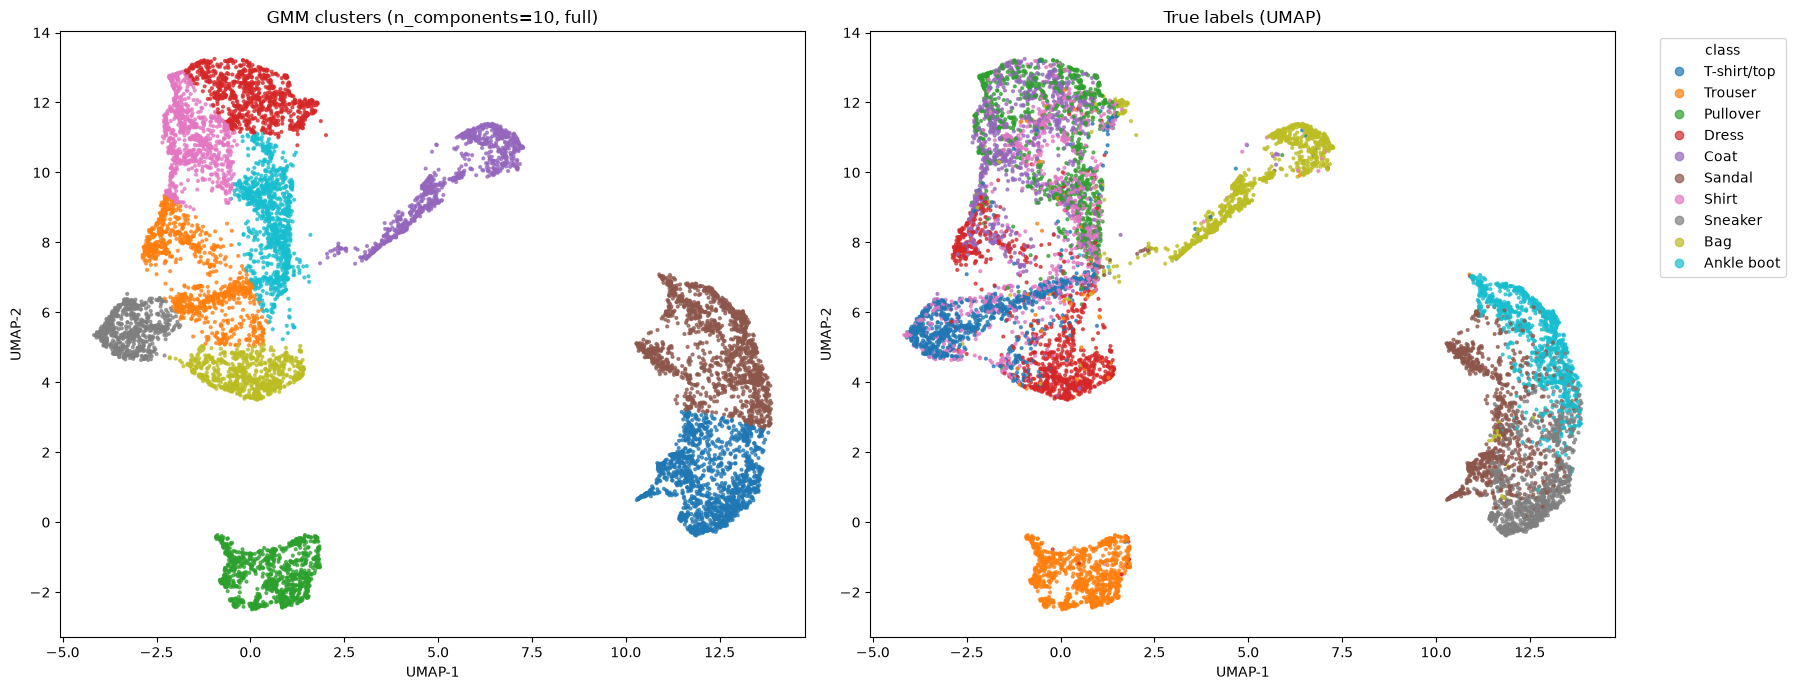

In [ ]:
# Visualize the GMM clusters on the UMAP embedding next to the true labels.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].scatter(
    embedding_fashion[:, 0], embedding_fashion[:, 1],
    c=gmm_labels, cmap="tab10", s=4, alpha=0.7
)
axes[0].set_title(f"GMM clusters (n_components={gmm.n_components}, {gmm.covariance_type})")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

scatter = axes[1].scatter(
    embedding_fashion[:, 0], embedding_fashion[:, 1],
    c=y_fashion, cmap="tab10", s=4, alpha=0.7
)
handles, _ = scatter.legend_elements()
axes[1].legend(handles, class_names, title="class", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].set_title("True labels (UMAP)")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()

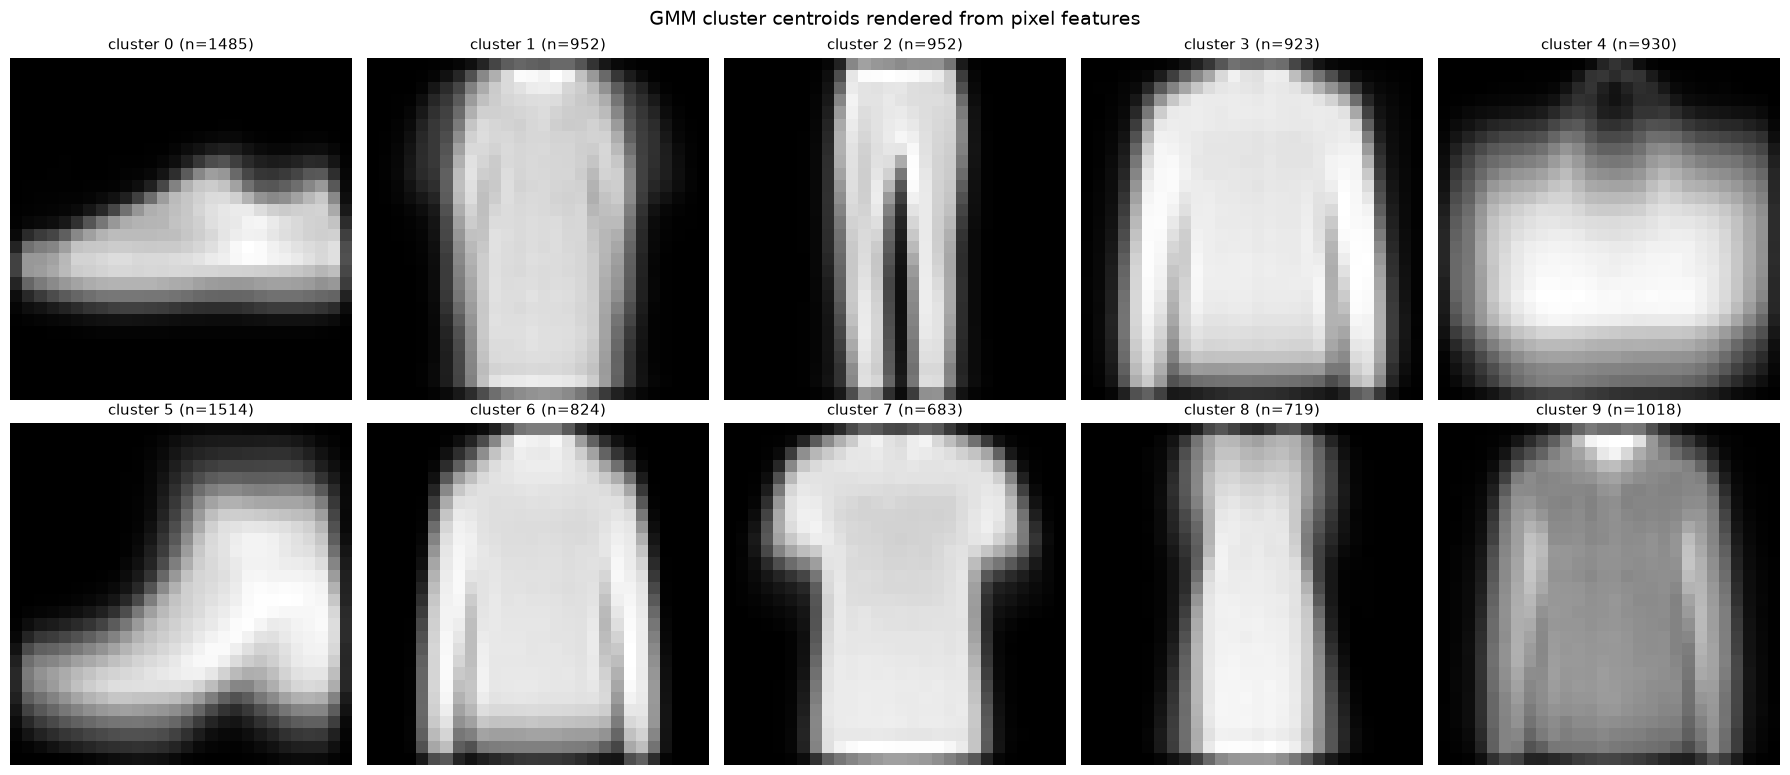

In [55]:
# Pixel centroid per cluster: mean of the 784 features over members, reshaped to 28x28
centroid_images = np.zeros((gmm.n_components, 28, 28))
for k in range(gmm.n_components):
    centroid_images[k] = X_fashion[gmm_labels == k].mean(axis=0).reshape(28, 28)

cluster_sizes = np.bincount(gmm_labels, minlength=gmm.n_components)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(centroid_images[k], cmap="gray")
    ax.set_title(f"cluster {k} (n={cluster_sizes[k]})", fontsize=11)
    ax.axis("off")
plt.suptitle("GMM cluster centroids rendered from pixel features", fontsize=14)
plt.tight_layout()
plt.show()

### 9.2.1 What each GMM cluster looks like (from pixel features)

Each cluster is a Gaussian in UMAP space, but every member maps back to a 784-pixel vector in
`X_fashion`. Averaging those vectors per cluster and reshaping to 28×28 gives a **pixel centroid** —
the "average garment" the model isolated in that component. Reading the figure above:

| Cl. | Rendered pattern | Interpretation |
|----:|------------------|----------------|
| 2   | Two-leg trouser silhouette | Clean **trousers**: narrow waist, two straight legs. The model found this purely from pixel layout — a single tight UMAP blob. |
| 4   | Box shape with handle | **Bags**: compact square body plus a looped handle. Geometrically unlike anything else, so UMAP keeps them isolated. |
| 5   | Tall boot with thick sole | **Ankle boots**: solid shaft over a wide flat base. Reads clearly as a boot. |
| 0   | Low, rounded shoe | **Sneakers/sandals**: flat sole, low rounded upper — the "flat footwear" component split away from boots. |
| 7   | Broad torso, short sleeves | **T-shirts/tops**: shoulder-width body, short sleeves, faint collar. The cleanest upper-garment centroid. |
| 8   | Narrow, slightly flared torso | **Dresses**: slimmer than a top, flaring slightly toward the hem. |
| 6   | Long garment, closed front | **Coats**: long body, closed front, sleeves. Still recognisable, but blobier than 7/8. |
| 3, 9 | Mushy "average top" | **Mixed upper garments**: the centroid is a blurred torso — pullover, coat and shirt pixels averaged together, so no single garment survives. |
| 1   | Blurred, directionless shape | **Leftover mix**: dresses, t-shirts, coats and shirts smear into an unreadable mean with no dominant pattern. |

- Clusters 2, 4, 0, 5 render as **recognisable silhouettes** (trousers, bag, flat shoe, boot): their
  member images are already pixel-distinct, so the model's components trace those boundaries exactly.
- Clusters 3, 6, 9, 1 render as **blurred garment blobs**: members are pixel-near pulls of
  tops/shirts/pullovers/coats, so the centroid becomes an average that matches no single class — the
  model cannot cleanly carve the upper-body garments apart.

- GMM splits the UMAP space into compact elliptical regions: the well-separated groups — shoes,
  trousers, bags — land in their own components, just as they did for DBSCAN and hierarchical
  clustering.
- The garments (tops, shirts, pullovers, coats) still share components: the Gaussians overlap
  exactly where those classes are nearly pixel-identical, so no hard boundary can separate them.

### 9.3 Cluster membership probabilities

In [53]:
# Soft membership probabilities
gmm_sample_idx = np.random.RandomState(42).choice(
    len(embedding_fashion), size=12, replace=False
)
proba_sample = embedding_fashion[gmm_sample_idx]

proba_df = pd.DataFrame(
    gmm.predict_proba(proba_sample),
    index=[f"point {i}" for i in gmm_sample_idx],
    columns=[f"cluster {k}" for k in range(gmm.n_components)],
)

proba_df.style.highlight_max(
    axis=1, subset=[f"cluster {k}" for k in range(gmm.n_components)]
)

,cluster 0,cluster 1,cluster 2,cluster 3,cluster 4,cluster 5,cluster 6,cluster 7,cluster 8,cluster 9
point 6252,0.000000,0.000026,0.000000,0.046491,0.000000,0.000000,0.953483,0.000000,0.000000,0.000000
point 4684,0.000000,0.004769,0.000000,0.000000,0.000110,0.000000,0.000000,0.000000,0.000000,0.995121
point 1731,0.000000,0.013006,0.000000,0.000000,0.000145,0.000000,0.000000,0.000000,0.000000,0.986849
point 4742,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
point 4521,0.000000,0.000093,0.000000,0.000000,0.000000,0.000000,0.000000,0.998103,0.001804,0.000000
point 6340,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
point 576,0.000071,0.000000,0.000000,0.000000,0.000000,0.999929,0.000000,0.000000,0.000000,0.000000
point 5202,0.000000,0.000645,0.000000,0.000000,0.000000,0.000000,0.002005,0.000000,0.000000,0.997349
point 6363,0.000000,0.710454,0.000000,0.000000,0.000000,0.000000,0.289546,0.000000,0.000000,0.000000
point 439,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
